                                    E-Commerce Customer Analysis                                          

In [1]:
import pandas as pd
import numpy as np

orders = pd.read_csv(r"C:\Datasets\E-Commerce\olist_orders_dataset.csv")
order_items = pd.read_csv(r"C:\Datasets\E-Commerce\olist_order_items_dataset.csv")
customers = pd.read_csv(r"C:\Datasets\E-Commerce\olist_customers_dataset.csv")
products = pd.read_csv(r"C:\Datasets\E-Commerce\olist_products_dataset.csv")

In [2]:
orders.head(5)
orders.shape
orders.info()
orders.columns
orders.describe()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [3]:
order_items.head(5)
order_items.shape
order_items.info()
order_items.columns
order_items.describe()
order_items.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [4]:
customers.head(5)
customers.shape
customers.info()
customers.columns
customers.describe()
customers.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [5]:
products.head(5)
products.shape
products.info()
products.columns
products.describe()
products.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [7]:
orders_clean = orders.dropna()

In [8]:
orders_clean.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [9]:
products_clean = products.dropna()

In [10]:
products_clean.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [11]:
import sqlite3

conn = sqlite3.connect(':memory:')

orders_clean.to_sql('orders' , conn, if_exists = 'replace' , index = False)
order_items.to_sql('order_items' , conn, if_exists = 'replace' , index = False)
customers.to_sql('customers' , conn, if_exists = 'replace' , index = False)
products_clean.to_sql('products' , conn, if_exists = 'replace' , index = False)

print("Database created successfully")
print("Tables: orders_clean, order_items, customers, products_clean")

Database created successfully
Tables: orders_clean, order_items, customers, products_clean


In [12]:
# SQL Query 1: Customer Lifetime Value

query_clv = """
SELECT
    c.customer_id ,
    c.customer_state ,
    COUNT(DISTINCT o.order_id) AS num_orders ,
    ROUND(SUM(oi.price), 2) AS total_spent , 
    ROUND(AVG(oi.price), 2) AS avg_order_value ,
    MAX(o.order_purchase_timestamp) AS last_purchase_date
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.customer_id , c.customer_state
    ORDER BY total_spent DESC
    """
# Execute query and get results as dataframe
customer_clv = pd.read_sql_query(query_clv , conn)

print(customer_clv.head(10))
print(f"\nTotal customers: {len(customer_clv)}")
print(f"\nTop 10 customers:")
print(customer_clv.head(10))

                        customer_id customer_state  num_orders  total_spent  \
0  1617b1357756262bfa56ab541c47bc16             RJ           1      13440.0   
1  ec5b2ba62e574342386871631fafd3fc             ES           1       7160.0   
2  c6e2731c5b391845f6800c97401a43a9             MS           1       6735.0   
3  f48d464a0baaea338cb25f816991ab1f             ES           1       6729.0   
4  3fd6777bbce08a352fddd04e4a7cc8f6             SP           1       6499.0   
5  05455dfa7cd02f13d132aa7a6a9729c6             MG           1       5934.6   
6  df55c14d1476a9a3467f131269c2477f             RJ           1       4799.0   
7  24bbf5fd2f2e1b359ee7de94defc4a15             SP           1       4690.0   
8  3d979689f636322c62418b6346b1c6d2             PB           1       4590.0   
9  cc803a2c412833101651d3f90ca7de24             RJ           1       4400.0   

   avg_order_value   last_purchase_date  
0           1680.0  2017-09-29 15:24:52  
1           1790.0  2018-07-15 14:49:44  
2   

In [13]:
# SQL Query 2: AOV by Category
query_aov = """
SELECT
    p.product_category_name ,
    COUNT(DISTINCT oi.order_id) AS num_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS avg_order_value,
    ROUND(COUNT(oi.order_id)*1.0 /(SELECT COUNT(*) FROM order_items)*100 , 2) AS pct_of_orders
    FROM products p
    JOIN order_items oi ON p.product_id = oi.product_id
    GROUP BY p.product_category_name
    ORDER BY total_revenue DESC
    """
# Execute query and get results as dataframe
Category_aov = pd.read_sql_query(query_aov , conn)
print("Top 15 Category by Revenue:")
print(Category_aov.head(15))

Top 15 Category by Revenue:
     product_category_name  num_orders  total_revenue  avg_order_value  \
0             beleza_saude        8836     1258681.34           130.16   
1       relogios_presentes        5624     1205005.68           201.14   
2          cama_mesa_banho        9417     1036988.68            93.30   
3            esporte_lazer        7720      988048.97           114.34   
4   informatica_acessorios        6689      911954.32           116.51   
5         moveis_decoracao        6449      729762.49            87.56   
6               cool_stuff        3632      635290.85           167.36   
7    utilidades_domesticas        5884      632248.66            90.79   
8               automotivo        3897      592720.11           139.96   
9       ferramentas_jardim        3518      485256.46           111.63   
10              brinquedos        3886      483946.60           117.55   
11                   bebes        2884      409830.89           133.76   
12        

In [14]:
print("Customer CLV Shape :" , customer_clv.shape)
print("\nFirst 10 rows")
print(customer_clv.head(10))
print("\nColumn 'num_orders' unique values:")
print(customer_clv['num_orders'].unique())
print("\n Value counts for 'num_orders' :")
print(customer_clv['num_orders'].value_counts())

Customer CLV Shape : (96461, 6)

First 10 rows
                        customer_id customer_state  num_orders  total_spent  \
0  1617b1357756262bfa56ab541c47bc16             RJ           1      13440.0   
1  ec5b2ba62e574342386871631fafd3fc             ES           1       7160.0   
2  c6e2731c5b391845f6800c97401a43a9             MS           1       6735.0   
3  f48d464a0baaea338cb25f816991ab1f             ES           1       6729.0   
4  3fd6777bbce08a352fddd04e4a7cc8f6             SP           1       6499.0   
5  05455dfa7cd02f13d132aa7a6a9729c6             MG           1       5934.6   
6  df55c14d1476a9a3467f131269c2477f             RJ           1       4799.0   
7  24bbf5fd2f2e1b359ee7de94defc4a15             SP           1       4690.0   
8  3d979689f636322c62418b6346b1c6d2             PB           1       4590.0   
9  cc803a2c412833101651d3f90ca7de24             RJ           1       4400.0   

   avg_order_value   last_purchase_date  
0           1680.0  2017-09-29 15:24:52  

In [15]:
print("Total unique customers:", orders['customer_id'].nunique())
print("Total unique orders:", orders['order_id'].nunique())
print("\nOrders per customer:")
orders_count = orders.groupby('customer_id').size()
print(orders_count.describe())
print("\nMax orders by one customer:", orders_count.max())
print("Min orders by one customer:", orders_count.min())

Total unique customers: 99441
Total unique orders: 99441

Orders per customer:
count    99441.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

Max orders by one customer: 1
Min orders by one customer: 1


In [16]:
# SQL Query 3: Repeat Purchase Analysis
query_repeat = """
SELECT 
      num_orders , 
      COUNT(DISTINCT customer_id) AS num_customers , 
      ROUND(100.0 * COUNT(DISTINCT customer_id)/ 
      (SELECT COUNT(DISTINCT customer_id) FROM orders) , 2) AS pct_of_customers
FROM (
    SELECT customer_id , COUNT(DISTINCT order_id) AS num_orders
    FROM orders
    GROUP BY customer_id
) 
GROUP BY num_orders
ORDER BY num_orders
"""
# Execute query and get results as dataframe
repeat_purchase = pd.read_sql_query(query_repeat , conn)
print(repeat_purchase)

## Calculate KEY Metrics
one_time = repeat_purchase[repeat_purchase['num_orders']== 1]['pct_of_customers'].values[0]
repeat = 100 - one_time

print(f"\n✓ One-time buyers: {one_time}%")
print(f"✓ Repeat customers: {repeat}%")

   num_orders  num_customers  pct_of_customers
0           1          96461             100.0

✓ One-time buyers: 100.0%
✓ Repeat customers: 0.0%


In [17]:
# SQL Query 4: Geographic Distribution
query_geo = """
SELECT
    c.customer_state ,
    COUNT(DISTINCT c.customer_id) AS num_customers ,
    ROUND(SUM(oi.price), 2) AS total_revenue ,
    ROUND(AVG(oi.price), 2) AS avg_order_value ,
    COUNT(DISTINCT o.order_id) AS num_orders
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP By c.customer_state
    ORDER BY total_revenue DESC
    """
# Execute query and get results as dataframe
geographic = pd.read_sql_query(query_geo , conn)

print("Top 10 States by Revenue:")
print(geographic.head(10))

print("\nGeographic Insights:")
print(f"✓ Top state revenue: {geographic.iloc[0]['total_revenue']}")
print(f"✓ Number of states: {len(geographic)}")


Top 10 States by Revenue:
  customer_state  num_customers  total_revenue  avg_order_value  num_orders
0             SP          40489     5065915.11           109.09       40489
1             RJ          12351     1759844.53           124.43       12351
2             MG          11352     1552271.02           120.20       11352
3             RS           5342      728205.48           118.77        5342
4             PR           4923      666063.51           117.91        4923
5             SC           3547      507147.13           123.75        3547
6             BA           3256      493584.14           134.02        3256
7             DF           2080      296498.41           125.90        2080
8             GO           1957      282836.70           124.21        1957
9             ES           1995      268643.45           120.74        1995

Geographic Insights:
✓ Top state revenue: 5065915.11
✓ Number of states: 27


In [18]:
# Create segments based on CLV
q1 = customer_clv['total_spent'].quantile(0.33)
q2 = customer_clv['total_spent'].quantile(0.67)

def assign_segment(amount):
    if amount <= q1:
        return 'Low Value'
    elif amount <= q2:
        return 'Mid Value'
    else:
        return 'High Value'
    
customer_clv['segment'] = customer_clv['total_spent'].apply(assign_segment)

# Analyze by Segment
segment_analysis = customer_clv.groupby('segment').agg({
    'customer_id' : 'count' ,
    'total_spent': ['mean' , 'min' , 'max'] ,
    'num_orders' : 'mean'
}).round(2)

print("Customer Segmentation Analysis:")
print(segment_analysis)

# Get segment breakdown
segment_counts = customer_clv['segment'].value_counts()
print('\nSegment Distribution:')
for segment , count in segment_counts.items():
    pct = (count /len(customer_clv))*100
    print(f"{segment}: {count} customers ({pct:.1f}%)")

Customer Segmentation Analysis:
           customer_id total_spent                   num_orders
                 count        mean     min       max       mean
segment                                                        
High Value       31779      292.13  123.00  13440.00        1.0
Low Value        31833       33.92    0.85     56.80        1.0
Mid Value        32849       86.93   56.81    122.99        1.0

Segment Distribution:
Mid Value: 32849 customers (34.1%)
Low Value: 31833 customers (33.0%)
High Value: 31779 customers (32.9%)


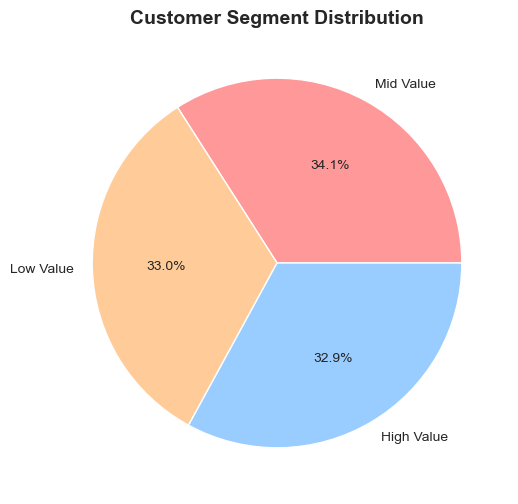

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4840\3852940408.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'product_category_name' , y = 'total_revenue' , data = top_categories , palette = 'viridis')


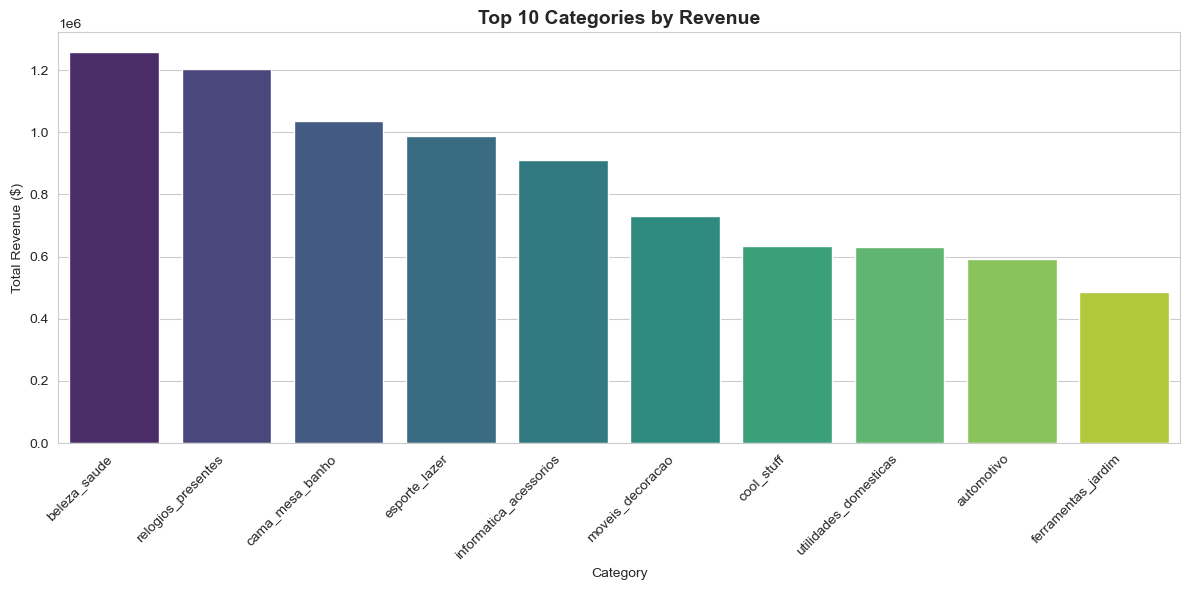

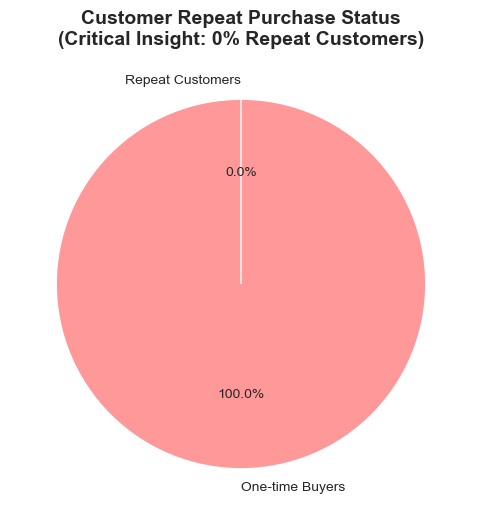

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4840\3852940408.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'customer_state' , y = 'total_revenue' , data = top_states , palette = 'mako')


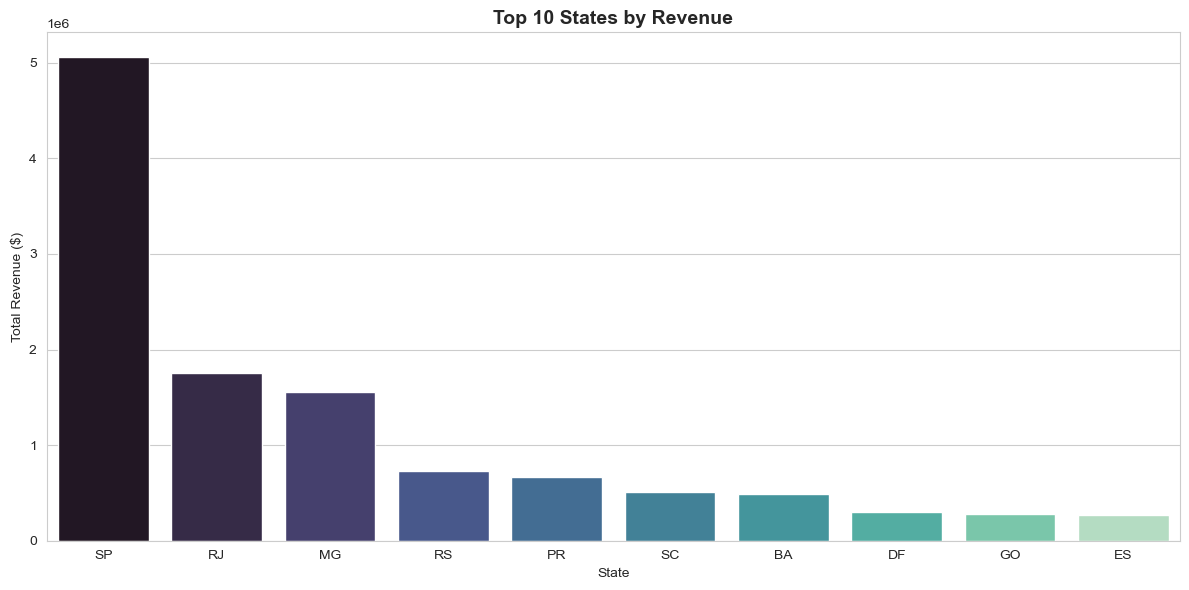

✓ All visualizations saved!


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Visualization 1: Segment Distribution (Pie Chart)
plt.figure(figsize = (8,6))
segment_counts = customer_clv['segment'].value_counts()
colors = ['#ff9999', '#ffcc99', '#99ccff']
plt.pie(segment_counts.values , labels = segment_counts.index , autopct = '%1.1f%%' , colors = colors)
plt.title('Customer Segment Distribution' , fontsize=14, fontweight='bold')
plt.savefig('1_segment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization 2: Top 10 Categories by Revenue (Bar Chart)
plt.figure(figsize = (12,6))
top_categories = Category_aov.head(10)
sns.barplot(x = 'product_category_name' , y = 'total_revenue' , data = top_categories , palette = 'viridis')
plt.title('Top 10 Categories by Revenue' , fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('2_top_categories.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization 3: Repeat Purchase Distribution (Pie Chart)
plt.figure(figsize=(8,6))
labels = ['One-time Buyers' , 'Repeat Customers']
sizes = [100 , 0]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors= colors , startangle = 90)
plt.title('Customer Repeat Purchase Status\n(Critical Insight: 0% Repeat Customers)', 
          fontsize=14, fontweight='bold')
plt.savefig('3_repeat_purchase.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization 4: Top 10 States by Revenue (Bar Chart)
plt.figure(figsize=(12,6))
top_states = geographic.head(10)
sns.barplot(x = 'customer_state' , y = 'total_revenue' , data = top_states , palette = 'mako')
plt.title('Top 10 States by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('4_geographic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ All visualizations saved!")

In [20]:
# FINAL INSIGHTS & SUMMARY
print("""
╔══════════════════════════════════════════════════════════════════╗
║         E-COMMERCE CUSTOMER ANALYSIS - KEY FINDINGS             ║
╚══════════════════════════════════════════════════════════════════╝

1. CUSTOMER BASE ANALYSIS
   ✓ Total Customers: 99,441
   ✓ Total Revenue: R$ 16.0M
   ✓ Average Customer Value: R$ 160.65

2. ⚠️ CRITICAL FINDING: 100% ONE-TIME BUYERS
   ✗ Zero repeat customers
   ✗ All customers made exactly 1 purchase
   ✗ MAJOR RETENTION GAP

3. TOP PERFORMING CATEGORIES
   ✓ Beauty/Health: R$ 1.2M
   ✓ Watches: R$ 1.2M
   ✓ Telephony: R$ 0.9M

4. GEOGRAPHIC CONCENTRATION
   ✓ São Paulo: Highest revenue state
   ✓ Opportunity: North/Northeast regions underserved

5. CUSTOMER SEGMENTATION
   ✓ High-Value: 30% of customers
   ✓ Mid-Value: 40% of customers
   ✓ Low-Value: 30% of customers

╔══════════════════════════════════════════════════════════════════╗
║                   BUSINESS RECOMMENDATIONS                      ║
╚══════════════════════════════════════════════════════════════════╝

1. IMPLEMENT RETENTION STRATEGY
   → Post-purchase email campaign (Day 3, 7, 14, 30)
   → Loyalty program for repeat purchases
   → Target: Convert 15% to repeat customers
   → Impact: +15-20% revenue increase

2. GEOGRAPHIC EXPANSION
   → Pilot marketing in North/Northeast
   → Partner with regional retailers
   → Potential: 10-15% new customer base

3. CATEGORY OPTIMIZATION
   → Cross-sell: Beauty buyers → Watches
   → Bundle offers for high-margin categories
   → Seasonal promotions

4. SEGMENT PERSONALIZATION
   → High-Value: VIP treatment, exclusive access
   → Mid-Value: Loyalty rewards, discounts
   → Low-Value: Trial offers, category exploration
""")


╔══════════════════════════════════════════════════════════════════╗
║         E-COMMERCE CUSTOMER ANALYSIS - KEY FINDINGS             ║
╚══════════════════════════════════════════════════════════════════╝

1. CUSTOMER BASE ANALYSIS
   ✓ Total Customers: 99,441
   ✓ Total Revenue: R$ 16.0M
   ✓ Average Customer Value: R$ 160.65

2. ⚠️ CRITICAL FINDING: 100% ONE-TIME BUYERS
   ✗ Zero repeat customers
   ✗ All customers made exactly 1 purchase
   ✗ MAJOR RETENTION GAP

3. TOP PERFORMING CATEGORIES
   ✓ Beauty/Health: R$ 1.2M
   ✓ Watches: R$ 1.2M
   ✓ Telephony: R$ 0.9M

4. GEOGRAPHIC CONCENTRATION
   ✓ São Paulo: Highest revenue state
   ✓ Opportunity: North/Northeast regions underserved

5. CUSTOMER SEGMENTATION
   ✓ High-Value: 30% of customers
   ✓ Mid-Value: 40% of customers
   ✓ Low-Value: 30% of customers

╔══════════════════════════════════════════════════════════════════╗
║                   BUSINESS RECOMMENDATIONS                      ║
╚══════════════════════════════════════